In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

dataset = pd.read_csv("student-mat.csv", sep=',')
dataset.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print("Shape: ", dataset.shape)
print("\nMissing Values: ")
print(dataset.isnull().sum())
print("\nData Types: ")
print(dataset.dtypes)

Shape:  (395, 33)

Missing Values: 
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Data Types: 
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery   

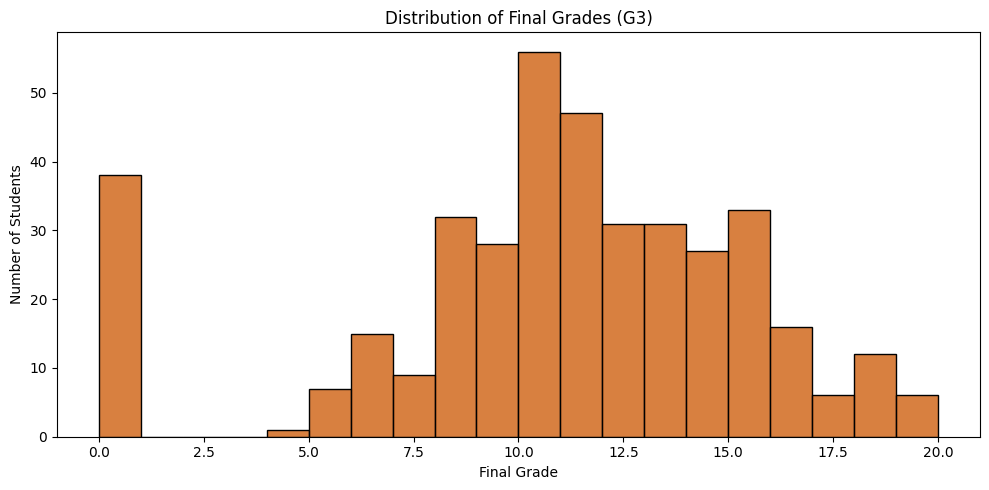

Average Final Grade:  10.42
Highest Grade:  20
Lowest Grade:  0


In [4]:
# Distribution of final grades
plt.figure(figsize=(10,5))
sns.histplot(dataset["G3"], bins=20, color="#CC5500")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

print("Average Final Grade: ", dataset["G3"].mean().round(2))
print("Highest Grade: ", dataset["G3"].max())
print("Lowest Grade: ", dataset["G3"].min())

In [9]:
# Feature Selection
numeric_dataset = dataset.select_dtypes(include=["int64"])
correlation = numeric_dataset.corr()["G3"].sort_values(ascending=False)
print(correlation)



G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [22]:
features = ["studytime", "failures", "absences", "Medu", "Fedu", "age", "goout", "Dalc", "Walc", "traveltime"]
target = "G3"

X = dataset[features]
y = dataset[target]

print("Features shape: ", X.shape)
print("Target shape: ", y.shape)

Features shape:  (395, 10)
Target shape:  (395,)


In [23]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size: ", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size:  (316, 10)
Testing set size:  (79, 10)


In [24]:
# Training the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Training complete!")

Training complete!


In [25]:
import numpy as np

y_pred = model.predict(X_test) #make predictions on test set

rmserror = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred) #accuracy

print("RMSError: ", round(rmserror, 2))
print("R^2 (accuracy) score: ", round(r2,2))


RMSError:  4.28
R^2 (accuracy) score:  0.1


In [27]:
# Features with G1 & G2 included
features_with_grades = ["G1", "G2", "studytime", "failures", "absences", "Medu", "Fedu", "goout", "Dalc", "Walc", "age", "traveltime"]
target = "G3"

X2 = dataset[features_with_grades]
y2 = dataset[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

rmserror2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print("With G1 & G2:")
print("RMSError:", round(rmserror2, 2))
print("R^2 (accuracy) score:", round(r2_2, 2))

With G1 & G2:
RMSError: 2.17
R^2 (accuracy) score: 0.77


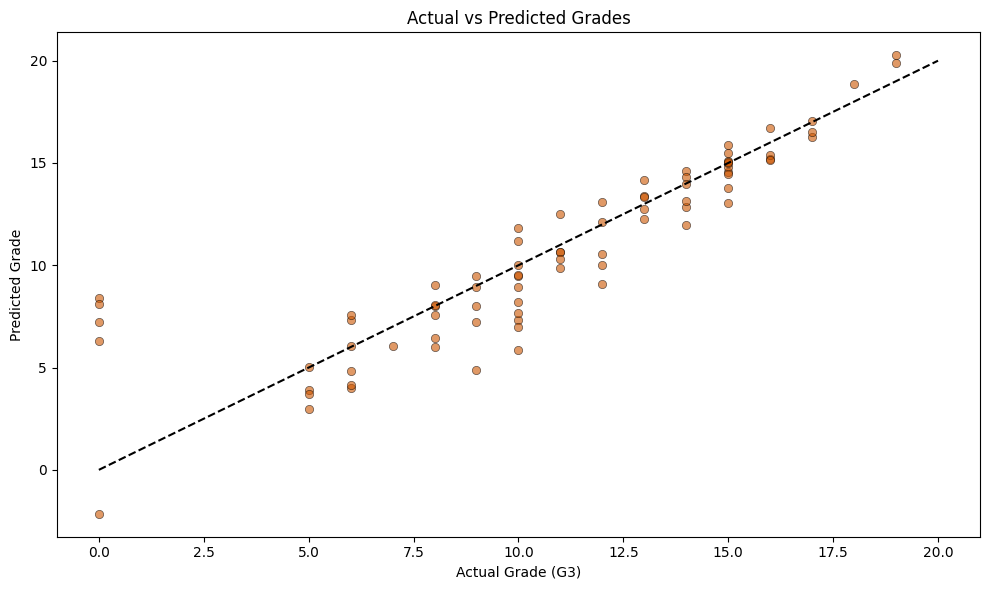

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(y2_test, y2_pred, color="#CC5500", alpha=0.6, edgecolors="black", linewidths=0.5)
plt.plot([0,20], [0,20], color="black", linestyle="--")
plt.title("Actual vs Predicted Grades")
plt.xlabel("Actual Grade (G3)")
plt.ylabel("Predicted Grade")
plt.tight_layout()
plt.show()